In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
from scipy import interpolate
from scipy.stats import linregress
from voigt_fit_lib import *

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# z=1.16 pLLS

Load in NUV data

In [3]:
spec = fits.open('PG1522+101_NUV_wavecal_new.fits')

In [4]:
spec_arr = pd.DataFrame(spec[1].data).to_numpy()

wav = spec_arr[:,0]
flux = spec_arr[:,1]
err = spec_arr[:,2]

Lyman series

In [5]:
atom_dat = np.loadtxt('atom.dat', dtype='str')

In [6]:
HI_dat = atom_dat[5:31]

In [7]:
HI_dat

array([['HI', '930.7483', '0.004814', '1.236E7'],
       ['HI', '926.2257', '0.003183', '8.255E6'],
       ['HI', '923.1504', '0.002216', '5.785E6'],
       ['HI', '920.9631', '0.001605', '4.210E6'],
       ['HI', '919.3514', '0.00120', '3.160E6'],
       ['HI', '918.1294', '0.000921', '2.432E6'],
       ['HI', '917.1806', '7.226e-4', '1.911E6'],
       ['HI', '916.429', '0.000577', '1.529E6'],
       ['HI', '915.824', '0.000469', '1.243E6'],
       ['HI', '915.329', '0.000386', '1.024E6'],
       ['HI', '914.919', '0.000321', '8.533E5'],
       ['HI', '914.576', '0.000270', '7.186E5'],
       ['HI', '914.286', '0.000230', '6.109E5'],
       ['HI', '914.039', '0.000197', '5.237E5'],
       ['HI', '913.826', '0.000170', '4.523E5'],
       ['HI', '913.641', '0.000148', '3.933E5'],
       ['HI', '913.480', '0.000129', '3.443E5'],
       ['HI', '913.339', '0.000114', '3.030E5'],
       ['HI', '913.215', '0.000101', '2.679E5'],
       ['HI', '913.104', '0.000089', '2.382E5'],
       ['HI', 

In [8]:
HI_wavs = np.float_(HI_dat[:,1])

In [9]:
z_abs = 1.16590988

Plotting spectrum

In [10]:
wav_rest = wav/(1+z_abs)

Text(0, 0.5, 'Flux (ergs/cm${}^2$/s/Å)')

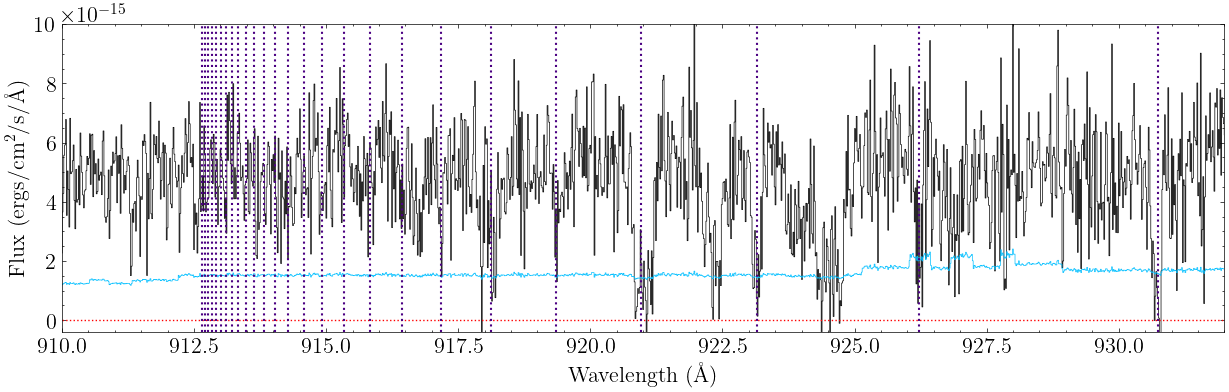

In [11]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.step(wav_rest, flux, where='mid', lw=0.5)
ax.step(wav_rest, err, where='mid', lw=0.5)

ax.axhline(0, linestyle=':', color='red')
 
for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')
    
ax.set_xlim(910, 932)
ax.set_ylim(-0.4e-15, 1e-14)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (ergs/cm${}^2$/s/Å)')

Continuum normalization

In [12]:
cont_params = [
             [915.824, 6.017716986790326e-15, 3.8444315952799605e-19], 
             [916.429, 5.251489132520212e-15, -2.2299257239280145e-20],
             [917.1806, 4.921701686541754e-15, 1.1125866508328276e-18],
             [918.1294, 5.125708647619499e-15, -3.556081716529457e-19],
             [919.3514, 5.490916126836431e-15, 1.2048755995847964e-18],
             [920.9631, 5.320379772153224e-15, 2.0403373503388168e-19],
             [923.1504, 5.292222391716257e-15, 9.650693252142945e-19],
             [926.2257, 5.60310210814473e-15, 4.378464250701585e-19],
             [930.7483, 4.849598958492894e-15, 1.109431132298648e-19],
]

In [13]:
cont_flux = np.zeros(len(wav_rest))

for i in range(len(cont_params)):
    
    # Compute local continuum flux
    wav0_rest = cont_params[i][0]
    a0 = cont_params[i][1]
    a1 = cont_params[i][2]
    
    # Conversion from velocity parameters to rest wavelength parameters
    # See derivation in research notes
    cont_flux_local = (a0-a1*3e+5) + (a1/wav0_rest)*wav_rest*3e+5
        
    # Find relevant wavelengths
    
    # Before the first line
    if i == 0:
        wav_curr_hi = cont_params[i][0]*(1+300/3e+5)
        wav_next_lo = cont_params[i+1][0]*(1-300/3e+5)
        wav_mid_right = .5*(wav_curr_hi+wav_next_lo)    
        
        idx = wav_rest<=wav_mid_right
        
    # After the last line
    elif i == len(cont_params)-1:
        wav_prev_hi = cont_params[i-1][0]*(1+300/3e+5)
        wav_curr_lo = cont_params[i][0]*(1-300/3e+5)
        wav_mid_left = .5*(wav_prev_hi+wav_curr_lo)
        
        idx = wav_rest>wav_mid_left
    
    # For intermediate lines
    else:
        # Blueward midpoint
        wav_prev_hi = cont_params[i-1][0]*(1+300/3e+5)
        wav_curr_lo = cont_params[i][0]*(1-300/3e+5)
        wav_mid_left = .5*(wav_prev_hi+wav_curr_lo)
        
        # Redward midpoint
        wav_curr_hi = cont_params[i][0]*(1+300/3e+5)
        wav_next_lo = cont_params[i+1][0]*(1-300/3e+5)
        wav_mid_right = .5*(wav_curr_hi+wav_next_lo)     
        
        idx = (wav_rest>wav_mid_left)&(wav_rest<=wav_mid_right)
        
    cont_flux[idx] = cont_flux_local[idx]

Old method, ignore

In [14]:
#cont_wavs_lo = np.array([915.2, 916, 916.9, 917.3, 918.5, 919.9, 921.3, 924.9, 927, 931, 938.3])
#cont_wavs_hi = np.array([915.3, 916.2, 917.0, 917.4, 918.6, 920.3, 921.9, 925.3, 930, 937.2, 938.8])

In [15]:
def get_coords(x_win_lo_arr, x_win_hi_arr, x_arr, y_arr):
    
    # Outdated: IGNORE
    
    x_cent = .5*(x_win_lo_arr+x_win_hi_arr)
    y_cent = np.zeros(len(x_cent))
    
    for i in range(len(x_win_lo_arr)):
        
        x_lo = x_win_lo_arr[i]
        x_hi = x_win_hi_arr[i]
        
        idx = (x_arr>=x_lo)&(x_arr<=x_hi)
        
        res = linregress(x_arr[idx], y_arr[idx])
        y_cent[i] = res[0]*x_cent[i] + res[1]
        
    return x_cent, y_cent

In [16]:
#cont_cent, flux_cent = get_coords(cont_wavs_lo*(1+z_abs), cont_wavs_hi*(1+z_abs), wav, flux)
#cont_flux_interp = interpolate.interp1d(cont_cent, flux_cent, fill_value='extrapolate')
#cont_flux = cont_flux_interp(wav)

Text(0, 0.5, 'Flux (ergs/cm${}^2$/s/Å)')

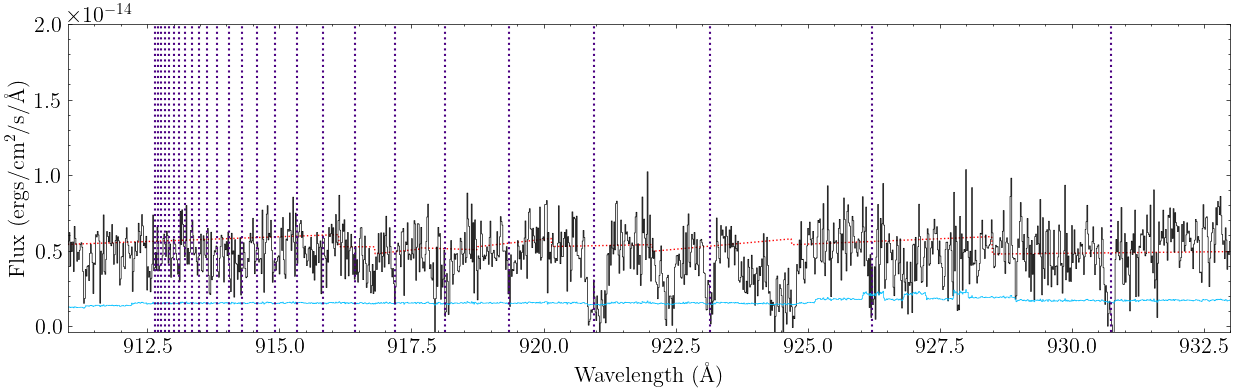

In [17]:
fig, ax = plt.subplots(1, figsize=(15,4))

#ax.scatter(cont_cent/(1+z_abs), flux_cent, color='red', marker='x', s=50)

ax.plot(wav_rest, cont_flux, color='red', linestyle=':')

ax.step(wav_rest, flux, where='mid', lw=0.5)
ax.step(wav_rest, err, where='mid', lw=0.5)


#ax.axhline(0, linestyle=':', color='red')
 
for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')
    
#for i in range(len(cont_wavs_lo)):
#    ax.axvspan(xmin=cont_wavs_lo[i], xmax=cont_wavs_hi[i], color='yellow', alpha=.1)
    
ax.set_xlim(911, 933)
ax.set_ylim(-0.4e-15, 2e-14)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (ergs/cm${}^2$/s/Å)')

Continuum normalization

In [18]:
flux_norm = flux/cont_flux
err_norm = err/cont_flux

Text(0, 0.5, 'Flux (continuum normalized)')

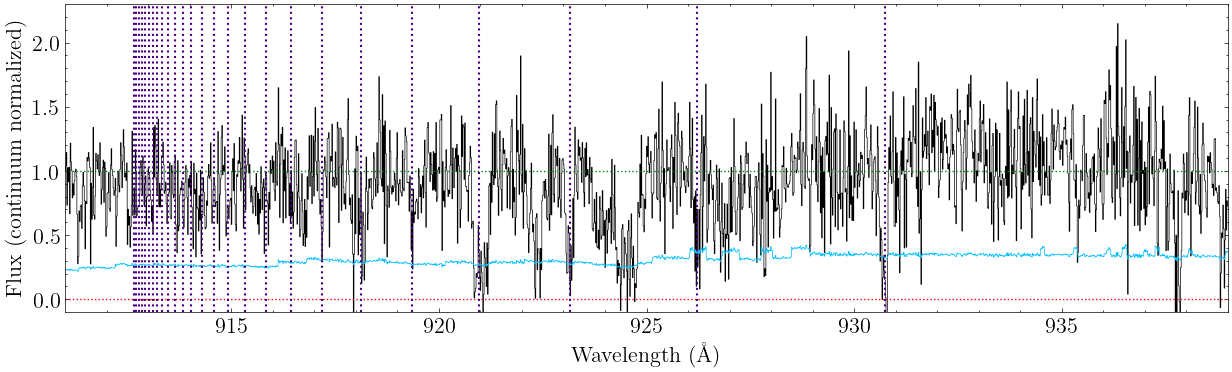

In [19]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.step(wav/(1+z_abs), flux_norm, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err_norm, where='mid', lw=0.5)

ax.axhline(0, linestyle=':', color='red')
ax.axhline(1, linestyle=':', color='green')

for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')

ax.set_yticks([0,0.5,1,1.5,2.0])
ax.set_xlim(911, 939)
ax.set_ylim(-0.1,2.3)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (continuum normalized)')

Voigt profile functions

In [20]:
lsf_fits = fits.open('PG1522_COS_NUV_wavcal2022_lsf.fits')

Model profile

In [21]:
A = 1.00797
v = np.arange(-400,400,1)

In [22]:
logN_1 = 16.1
b_1 = 19

#logN_2 = 16.4 # Old model
#b_2 = 21

logN_2 = 14.7 # New model
b_2 = 32

logN_3 = 14.5 # New model
b_3 = 22

In [23]:
z_abs_1 = 1.16590953

#z_abs_2 = z_abs_1 # Old model
z_abs_2 = z_abs_1-((1+z_abs_1)*24/3e+5)
z_abs_3 = z_abs_1+((1+z_abs_1)*21/3e+5)

In [24]:
def vp_gen(wav0_rest, z_abs, 
           v,
           logN, b, dv_c, 
           f, gamma_nu, A):
    
    lsf, v_lsf = grab_lsf(wav0_rest*(1+z_abs))
    
    gamma = (gamma_nu*(wav0_rest * 1e-10))*1e-3
    
    model = comp_model_spec_gen(v, np.array([[logN, b, dv_c]]), 
                                wav0_rest, f, gamma, A,
                                False,
                                lsf, v_lsf)[1]
        
    return model

In [25]:
def v_2_lam(v, wav0_rest):
    
    return wav0_rest*(1+v/3e+5)

In [26]:
def vp_lam_interp(wav, wav0_rest, vp):
    
    lam = v_2_lam(v, wav0_rest)
    vp_interp = interpolate.interp1d(x=lam, y=vp, fill_value='extrapolate')
    
    return vp_interp(wav)

In [27]:
def grab_lsf(wav0_obs):
    # Convert it to an array
    lsf_data = np.array(lsf_fits[1].data)

    # For each wavelength, isolate LSFs
    lsf_wavs = []

    for i in range(len(lsf_data)):
        lsf_wavs.append(lsf_data[i][0])

    lsf_wavs = np.array(lsf_wavs)

    # Isolate the closest LSF
    lsf_idx = np.argmin(np.abs(wav0_obs-lsf_wavs))
    lsf = lsf_data[lsf_idx][2]

    # Also generate the velocity scale corresponding to the LSF
    delta_v = lsf_data[lsf_idx][1]
    lsf_central_idx = np.argmax(lsf)
    lsf_pix_rel = np.arange(0, len(lsf))-lsf_central_idx
    lsf_pix_v = delta_v*lsf_pix_rel

    # Finally store the LSF velocities and the profile itself
    return lsf, lsf_pix_v

In [28]:
model_1 = np.ones(len(wav))
model_2 = np.ones(len(wav))
model_3 = np.ones(len(wav))

for i in range(len(HI_wavs)):
    
    # Model 1
    
    vp_1 = vp_gen(float(HI_dat[i,1]), z_abs_1, 
                v,
                logN_1, b_1, 0, 
                float(HI_dat[i,2]), float(HI_dat[i,3]), A)
    
    model_1 *= vp_lam_interp(wav/(1+z_abs_1), float(HI_dat[i,1]), vp_1)
    
    # Model 2
    
    vp_2 = vp_gen(float(HI_dat[i,1]), z_abs_2, 
                v,
                logN_2, b_2, 0, 
                float(HI_dat[i,2]), float(HI_dat[i,3]), A)
    
    model_2 *= vp_lam_interp(wav/(1+z_abs_2), float(HI_dat[i,1]), vp_2)
    
    # Model 3
    
    vp_3 = vp_gen(float(HI_dat[i,1]), z_abs_3, 
                v,
                logN_3, b_3, 0, 
                float(HI_dat[i,2]), float(HI_dat[i,3]), A)
    
    model_3 *= vp_lam_interp(wav/(1+z_abs_3), float(HI_dat[i,1]), vp_3)

In [29]:
ll_idx = np.argmin(np.abs(wav/(1+z_abs) - 913.006))

In [30]:
model_1[:ll_idx+1] = model_1[ll_idx+1]
model_2[:ll_idx+1] = model_2[ll_idx+1]
model_3[:ll_idx+1] = model_3[ll_idx+1]

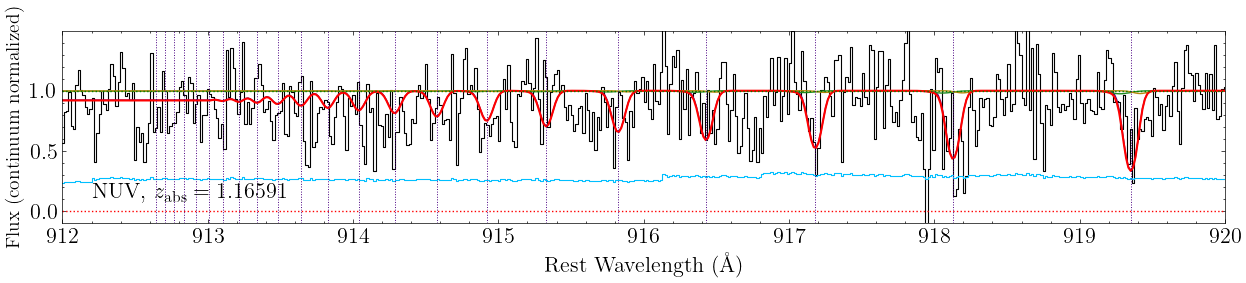

In [32]:
fig, ax = plt.subplots(1, figsize=(15,2.5))

ax.step(wav/(1+z_abs), flux_norm, where='mid', lw=0.8)
ax.step(wav/(1+z_abs), err_norm, where='mid', lw=0.8)

#ax.plot(wav/(1+z_abs_1), model_1, lw=1, color='indigo', label=r'$\log N = 16.1, b = 19$')
#ax.plot(wav/(1+z_abs_1), model_2, lw=1, color='indigo', label=r'$\log N = 16.4, b = 21$', linestyle='--')

ax.plot(wav/(1+z_abs_1), model_1, lw=1, color='indigo') #label=r'$\log (N_\mathrm{HI}) = 16.1, b = 19, v_c = 0$')
ax.plot(wav/(1+z_abs_1), model_2, lw=1, color='forestgreen') #label=r'$\log (N_\mathrm{HI}) = 14.7, b = 31, v_c = -24$')
ax.plot(wav/(1+z_abs_1), model_3, lw=1, color='darkgoldenrod') #label=r'$\log (N_\mathrm{HI}) = 14.4, b = 22, v_c = 22$')

ax.plot(wav/(1+z_abs_1), model_1*model_2, lw=1.5, color='red')#, label='Total')

ax.axhline(0, linestyle=':', color='red')
ax.axhline(1, linestyle=':', color='green')

for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=0.7, color='indigo')


ax.set_yticks([0,0.5,1])
ax.set_xlim(912, 920)
ax.set_ylim(-0.1,1.5)
ax.set_xlabel('Rest Wavelength (Å)')
ax.set_ylabel('Flux (continuum normalized)', fontsize=14)

ax.text(912.2, 0.1, r'NUV, $z_\mathrm{abs}=1.16591$')
#ax.legend(loc = 'lower left')
plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_HI.pdf'.format(str(z_abs_1), str(z_abs_1).replace('.', '_')), dpi=300)

Load in STIS data

In [3]:
spec = fits.open('PG1522+101_E230M_new.fits')

In [4]:
spec_arr = pd.DataFrame(spec[1].data).to_numpy()

wav = spec_arr[:,0]
flux = spec_arr[:,1]
err = spec_arr[:,2]

Lyman series

In [5]:
atom_dat = np.loadtxt('atom.dat', dtype='str')

In [6]:
HI_dat = atom_dat[4:10]

In [7]:
HI_dat

array([['HI', '937.8035', '0.007799', '2.450E7'],
       ['HI', '930.7483', '0.004814', '1.236E7'],
       ['HI', '926.2257', '0.003183', '8.255E6'],
       ['HI', '923.1504', '0.002216', '5.785E6'],
       ['HI', '920.9631', '0.001605', '4.210E6'],
       ['HI', '919.3514', '0.00120', '3.160E6']], dtype='<U12')

In [8]:
HI_wavs = np.float_(HI_dat[:,1])

In [9]:
z_abs = 1.16590988

Plotting spectrum in raw flux units

Text(0, 0.5, 'Flux (ergs/cm${}^2$/s/Å)')

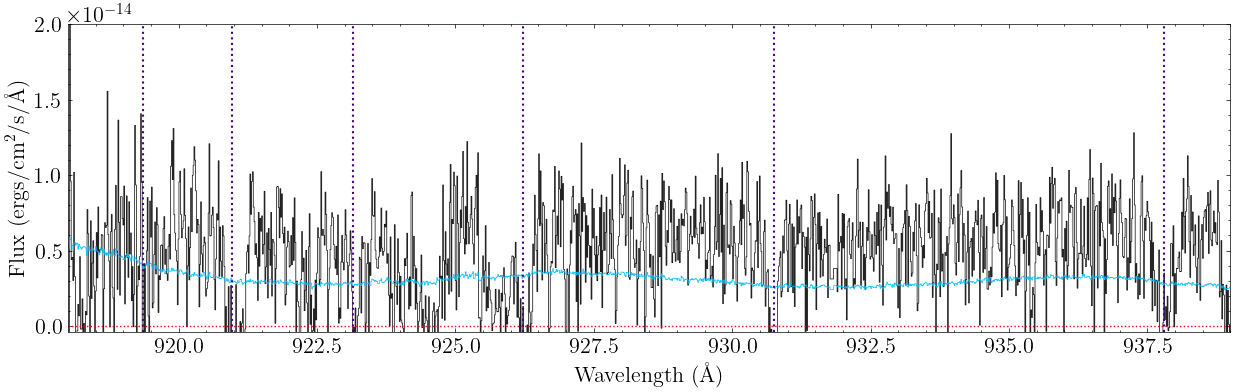

In [11]:
fig, ax = plt.subplots(1, figsize=(15,4))


ax.step(wav/(1+z_abs), flux, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err, where='mid', lw=0.5)

ax.axhline(0, linestyle=':', color='red')
 
for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')
    
ax.set_xlim(918, 939)
ax.set_ylim(-0.4e-15, 2e-14)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (ergs/cm${}^2$/s/Å)')

Continuum normalization

In [55]:
cont_wavs_lo = np.array([918.7, 919.9, 921.3, 924.9, 927, 931, 938.3])
cont_wavs_hi = np.array([919.0, 920.3, 921.9, 925.3, 930, 937.2, 938.8])

In [56]:
def get_coords(x_win_lo_arr, x_win_hi_arr, x_arr, y_arr):
    
    x_cent = .5*(x_win_lo_arr+x_win_hi_arr)
    y_cent = np.zeros(len(x_cent))
    
    for i in range(len(x_win_lo_arr)):
        
        x_lo = x_win_lo_arr[i]
        x_hi = x_win_hi_arr[i]
        
        idx = (x_arr>=x_lo)&(x_arr<=x_hi)
        
        res = linregress(x_arr[idx], y_arr[idx])
        y_cent[i] = res[0]*x_cent[i] + res[1]
        
    return x_cent, y_cent

In [12]:
cont_cent, flux_cent = get_coords(cont_wavs_lo*(1+z_abs), cont_wavs_hi*(1+z_abs), wav, flux)

In [13]:
cont_flux_interp = interpolate.interp1d(cont_cent, flux_cent, fill_value='extrapolate')

In [14]:
cont_flux = cont_flux_interp(wav)

Text(0, 0.5, 'Flux (ergs/cm${}^2$/s/Å)')

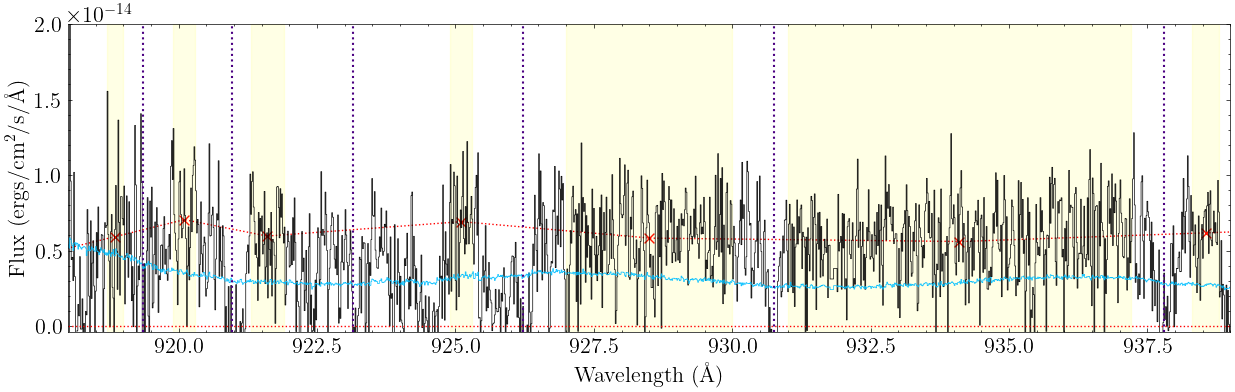

In [16]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.scatter(cont_cent/(1+z_abs), flux_cent, color='red', marker='x', s=50)

ax.plot(wav/(1+z_abs), cont_flux, color='red', linestyle=':')

ax.step(wav/(1+z_abs), flux, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err, where='mid', lw=0.5)


ax.axhline(0, linestyle=':', color='red')
 
for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')
    
for i in range(len(cont_wavs_lo)):
    ax.axvspan(xmin=cont_wavs_lo[i], xmax=cont_wavs_hi[i], color='yellow', alpha=.1)
    
ax.set_xlim(918, 939)
ax.set_ylim(-0.4e-15, 2e-14)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel(r'Flux (ergs/cm${}^2$/s/Å)')

Continuum normalization

In [17]:
flux_norm = flux/cont_flux
err_norm = err/cont_flux

Text(0, 0.5, 'Flux (continuum normalized)')

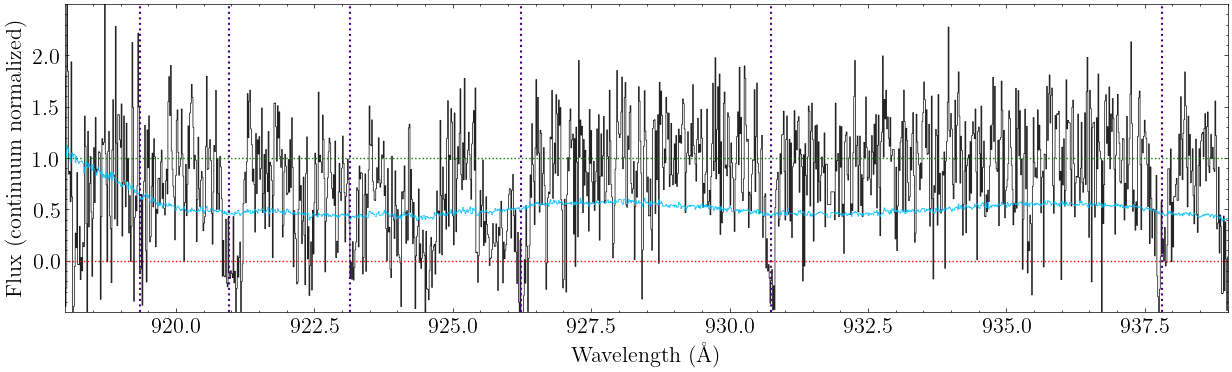

In [18]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.step(wav/(1+z_abs), flux_norm, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err_norm, where='mid', lw=0.5)

ax.axhline(0, linestyle=':', color='red')
ax.axhline(1, linestyle=':', color='green')

for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')

ax.set_yticks([0,0.5,1, 1.5, 2])
ax.set_xlim(918, 939)
ax.set_ylim(-0.5,2.5)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (continuum normalized)')

Voigt profile functions

In [19]:
lsf_fits = fits.open('PG1522_STIS_NUV_wavcal2022_lsf.fits')

In [20]:
def vp_gen(wav0_rest, z_abs, 
           v,
           logN, b, dv_c, 
           f, gamma_nu, A):
    
    lsf, v_lsf = grab_lsf(wav0_rest*(1+z_abs))
    
    gamma = (gamma_nu*(wav0_rest * 1e-10))*1e-3
    
    model = comp_model_spec_gen(v, np.array([[logN, b, dv_c]]), 
                                wav0_rest, f, gamma, A,
                                False,
                                lsf, v_lsf)[1]
        
    return model

In [21]:
def v_2_lam(v, wav0_rest):
    
    return wav0_rest*(1+v/3e+5)

In [22]:
def vp_lam_interp(wav, wav0_rest, vp):
    
    lam = v_2_lam(v, wav0_rest)
    vp_interp = interpolate.interp1d(x=lam, y=vp, fill_value='extrapolate')
    
    return vp_interp(wav)

In [23]:
def grab_lsf(wav0_obs):
    # Convert it to an array
    lsf_data = np.array(lsf_fits[1].data)

    # For each wavelength, isolate LSFs
    lsf_wavs = []

    for i in range(len(lsf_data)):
        lsf_wavs.append(lsf_data[i][0])

    lsf_wavs = np.array(lsf_wavs)

    # Isolate the closest LSF
    lsf_idx = np.argmin(np.abs(wav0_obs-lsf_wavs))
    lsf = lsf_data[lsf_idx][2]

    # Also generate the velocity scale corresponding to the LSF
    delta_v = lsf_data[lsf_idx][1]
    lsf_central_idx = np.argmax(lsf)
    lsf_pix_rel = np.arange(0, len(lsf))-lsf_central_idx
    lsf_pix_v = delta_v*lsf_pix_rel

    # Finally store the LSF velocities and the profile itself
    return lsf, lsf_pix_v

Model profile

In [24]:
A = 1.00797
v = np.arange(-400,400,1)

In [25]:
logN_1 = 16.4
b_1 = 21.4

logN_2 = 14.5
b_2 = 34

In [26]:
z_abs_1 = 1.16590988
z_abs_2 = z_abs_1-((1+z_abs_1)*24/3e+5)

In [27]:
def vp_gen(wav0_rest, z_abs, 
           v,
           logN, b, dv_c, 
           f, gamma_nu, A):
    
    lsf, v_lsf = grab_lsf(wav0_rest*(1+z_abs))
    
    gamma = (gamma_nu*(wav0_rest * 1e-10))*1e-3
    
    model = comp_model_spec_gen(v, np.array([[logN, b, dv_c]]), 
                                wav0_rest, f, gamma, A,
                                False,
                                lsf, v_lsf)[1]
        
    return model

In [28]:
def v_2_lam(v, wav0_rest):
    
    return wav0_rest*(1+v/3e+5)

In [29]:
def vp_lam_interp(wav, wav0_rest, vp):
    
    lam = v_2_lam(v, wav0_rest)
    vp_interp = interpolate.interp1d(x=lam, y=vp, fill_value='extrapolate')
    
    return vp_interp(wav)

In [30]:
model_1 = np.ones(len(wav))
model_2 = np.ones(len(wav))

for i in range(len(HI_wavs)):
    
    # Model 1
    
    vp_1 = vp_gen(float(HI_dat[i,1]), z_abs_1, 
                v,
                logN_1, b_1, 0, 
                float(HI_dat[i,2]), float(HI_dat[i,3]), A)
    
    model_1 *= vp_lam_interp(wav/(1+z_abs_1), float(HI_dat[i,1]), vp_1)
    
    # Model 2
    
    vp_2 = vp_gen(float(HI_dat[i,1]), z_abs_2, 
                v,
                logN_2, b_2, 0, 
                float(HI_dat[i,2]), float(HI_dat[i,3]), A)
    
    model_2 *= vp_lam_interp(wav/(1+z_abs_2), float(HI_dat[i,1]), vp_2)

Text(0, 0.5, 'Flux (continuum normalized)')

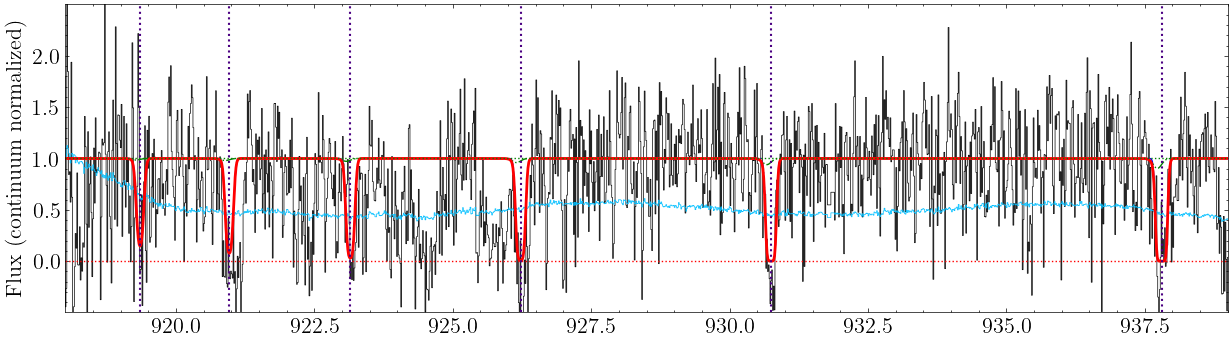

In [31]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.step(wav/(1+z_abs), flux_norm, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err_norm, where='mid', lw=0.5)
ax.plot(wav/(1+z_abs_1), model_1, lw=1, linestyle='-.', color='blue')
ax.plot(wav/(1+z_abs_1), model_2, lw=1, linestyle='-.', color='green')
ax.plot(wav/(1+z_abs_1), model_1*model_2, lw=2, color='red')


ax.axhline(0, linestyle=':', color='red')
ax.axhline(1, linestyle=':', color='green')

for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')

ax.set_yticks([0,0.5,1, 1.5, 2])
ax.set_xlim(918, 939)
ax.set_ylim(-0.5,2.5)
ax.set_ylabel('Flux (continuum normalized)')

#plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_HI.pdf'.format(str(z_sys),                                                                                       str(z_sys).replace('.', '_')), dpi=300)

# DRAFT - z=0.72 pLLS

Load in FUV data

In [3]:
spec = fits.open('PG1522+101_FUV_wavecal_new.fits')

In [4]:
spec_arr = pd.DataFrame(spec[1].data).to_numpy()

wav = spec_arr[:,0]
flux = spec_arr[:,1]
err = spec_arr[:,2]

Lyman series

In [5]:
atom_dat = np.loadtxt('atom.dat', dtype='str')

In [6]:
HI_dat = atom_dat[4:31]

In [7]:
HI_dat

array([['HI', '937.8035', '0.007799', '2.450E7'],
       ['HI', '930.7483', '0.004814', '1.236E7'],
       ['HI', '926.2257', '0.003183', '8.255E6'],
       ['HI', '923.1504', '0.002216', '5.785E6'],
       ['HI', '920.9631', '0.001605', '4.210E6'],
       ['HI', '919.3514', '0.00120', '3.160E6'],
       ['HI', '918.1294', '0.000921', '2.432E6'],
       ['HI', '917.1806', '7.226e-4', '1.911E6'],
       ['HI', '916.429', '0.000577', '1.529E6'],
       ['HI', '915.824', '0.000469', '1.243E6'],
       ['HI', '915.329', '0.000386', '1.024E6'],
       ['HI', '914.919', '0.000321', '8.533E5'],
       ['HI', '914.576', '0.000270', '7.186E5'],
       ['HI', '914.286', '0.000230', '6.109E5'],
       ['HI', '914.039', '0.000197', '5.237E5'],
       ['HI', '913.826', '0.000170', '4.523E5'],
       ['HI', '913.641', '0.000148', '3.933E5'],
       ['HI', '913.480', '0.000129', '3.443E5'],
       ['HI', '913.339', '0.000114', '3.030E5'],
       ['HI', '913.215', '0.000101', '2.679E5'],
       ['HI',

In [8]:
HI_wavs = np.float_(HI_dat[:,1])

In [9]:
z_abs = 0.72882547

Continuum normalization

In [10]:
cont_wavs_lo = np.array([918.5, 919.7, 922.3, 924, 928.8, 934.8, 938.7])
cont_wavs_hi = np.array([918.9, 919.9, 922.7, 925.2, 929.7, 937.2, 940])

In [12]:
cont_cent, flux_cent = get_coords(cont_wavs_lo*(1+z_abs), cont_wavs_hi*(1+z_abs), wav, flux)

In [13]:
cont_flux_interp = interpolate.interp1d(cont_cent, flux_cent, fill_value='extrapolate')

In [14]:
cont_flux = cont_flux_interp(wav)

Text(0, 0.5, 'Flux (ergs/cm${}^2$/s/Å)')

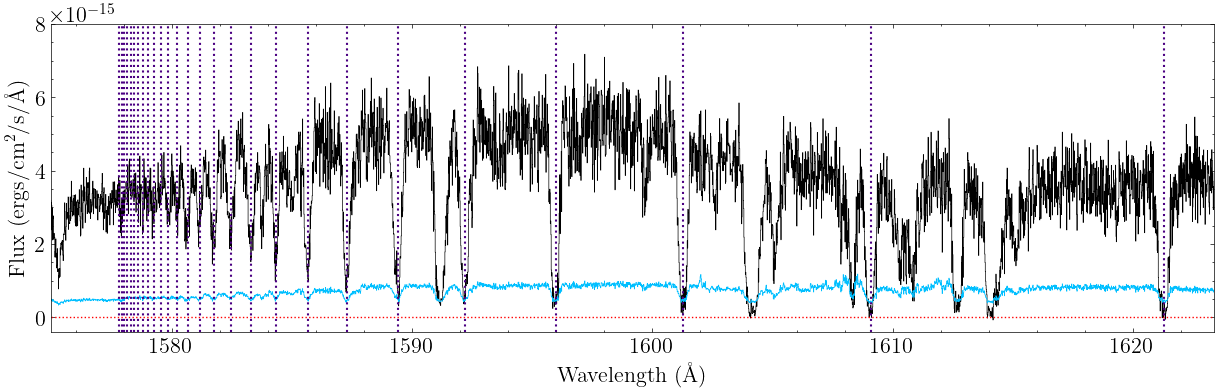

In [15]:
fig, ax = plt.subplots(1, figsize=(15,4))


ax.step(wav, flux, where='mid', lw=0.5)
ax.step(wav, err, where='mid', lw=0.5)

ax.axhline(0, linestyle=':', color='red')
 
for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i]*(1+z_abs), linestyle=':', lw=1.5, color='indigo')
    
ax.set_xlim(911*(1+z_abs), 939*(1+z_abs))
ax.set_ylim(-0.4e-15, 8e-15)
#ax.set_ylim(-0.2,1.5)
ax.set_xlabel('Wavelength (Å)')
#ax.set_ylabel('Normalized flux')
ax.set_ylabel(r'Flux (ergs/cm${}^2$/s/Å)')

Text(0, 0.5, 'Flux (ergs/cm${}^2$/s/Å)')

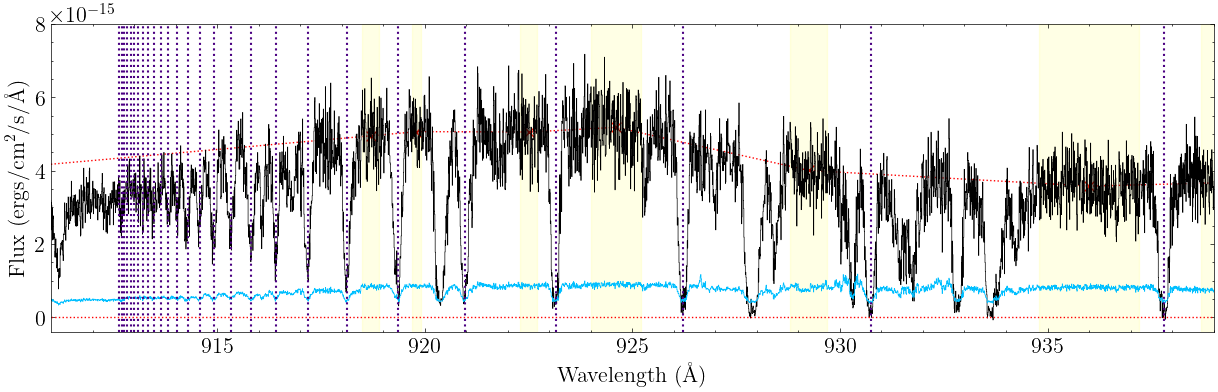

In [16]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.scatter(cont_cent/(1+z_abs), flux_cent, color='red', marker='x', s=50)

ax.plot(wav/(1+z_abs), cont_flux, color='red', linestyle=':')

ax.step(wav/(1+z_abs), flux, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err, where='mid', lw=0.5)


ax.axhline(0, linestyle=':', color='red')
 
for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')
    
for i in range(len(cont_wavs_lo)):
    ax.axvspan(xmin=cont_wavs_lo[i], xmax=cont_wavs_hi[i], color='yellow', alpha=.1)
    
ax.set_xlim(911, 939)
ax.set_ylim(-0.4e-15, 8e-15)
#ax.set_ylim(-0.2,1.5)
ax.set_xlabel('Wavelength (Å)')
#ax.set_ylabel('Normalized flux')
ax.set_ylabel(r'Flux (ergs/cm${}^2$/s/Å)')

Continuum normalization

In [17]:
flux_norm = flux/cont_flux
err_norm = err/cont_flux

Text(0, 0.5, 'Flux (continuum normalized)')

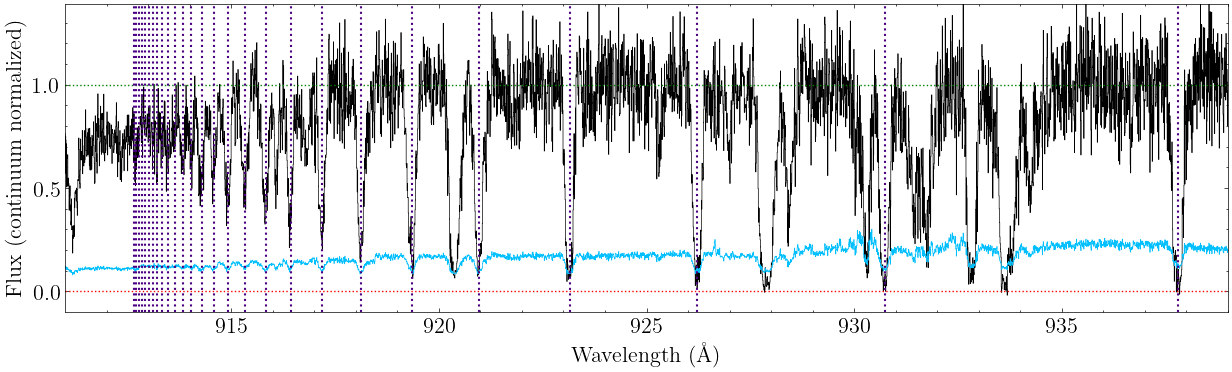

In [18]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.step(wav/(1+z_abs), flux_norm, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err_norm, where='mid', lw=0.5)

ax.axhline(0, linestyle=':', color='red')
ax.axhline(1, linestyle=':', color='green')

for i in range(len(HI_wavs)):
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')

ax.set_yticks([0,0.5,1])
ax.set_xlim(911, 939)
ax.set_ylim(-0.1,1.39)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (continuum normalized)')

Voigt profile functions

In [19]:
lsf_fits = fits.open('PG1522_COS_FUV_wavcal2022_lsf_ZQ.fits')

In [20]:
def grab_lsf(wav0_obs):
    # Convert it to an array
    lsf_data = np.array(lsf_fits[1].data)

    # For each wavelength, isolate LSFs
    lsf_wavs = []

    for i in range(len(lsf_data)):
        lsf_wavs.append(lsf_data[i][0])

    lsf_wavs = np.array(lsf_wavs)

    # Isolate the closest LSF
    lsf_idx = np.argmin(np.abs(wav0_obs-lsf_wavs))
    lsf = lsf_data[lsf_idx][2]

    # Also generate the velocity scale corresponding to the LSF
    delta_v = lsf_data[lsf_idx][1]
    lsf_central_idx = np.argmax(lsf)
    lsf_pix_rel = np.arange(0, len(lsf))-lsf_central_idx
    lsf_pix_v = delta_v*lsf_pix_rel

    # Finally store the LSF velocities and the profile itself
    return lsf, lsf_pix_v

Model profile

In [24]:
logN = 16.67
b = 25.6
A = 1.00797
v = np.arange(-400,400,1)

In [25]:
model = np.ones(len(wav))

for i in range(len(HI_wavs)):
    
    vp = vp_gen(float(HI_dat[i,1]), z_abs, 
                v,
                logN, b, 0, 
                float(HI_dat[i,2]), float(HI_dat[i,3]), A)
    model *= vp_lam_interp(wav/(1+z_abs), float(HI_dat[i,1]), vp)

In [26]:
ll_idx = np.argmin(np.abs(wav/(1+z_abs) - 913.006))

In [27]:
model[:ll_idx+1] = model[ll_idx+1]

In [28]:
z_sys = 0.72882547

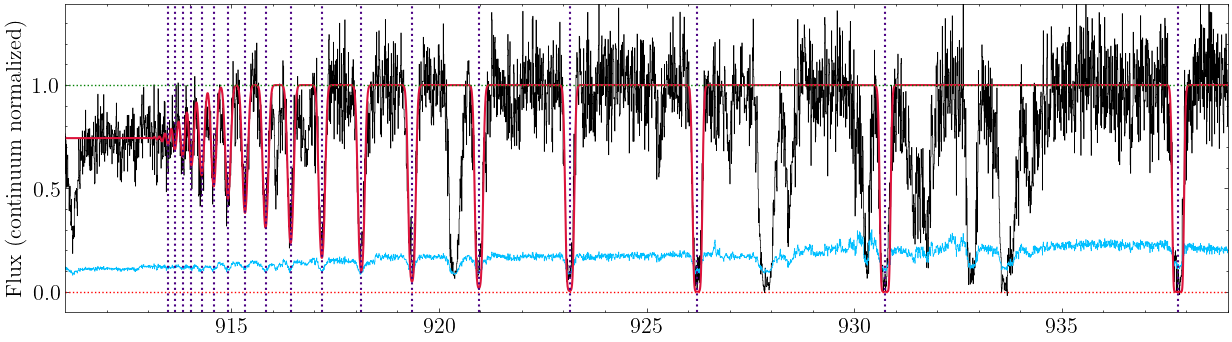

In [29]:
fig, ax = plt.subplots(1, figsize=(15,4))

ax.step(wav/(1+z_abs), flux_norm, where='mid', lw=0.5)
ax.step(wav/(1+z_abs), err_norm, where='mid', lw=0.5)
ax.plot(wav/(1+z_abs), model, lw=1.5)

ax.axhline(0, linestyle=':', color='red')
ax.axhline(1, linestyle=':', color='green')

for i in range(len(HI_wavs)-9):
    #print(HI_wavs[i])
    ax.axvline(HI_wavs[i], linestyle=':', lw=1.5, color='indigo')

ax.set_xlim(911, 939)
ax.set_yticks([0, 0.5, 1])
#ax.set_ylim(-1e-15, 8e-15)
ax.set_ylim(-0.1,1.39)
#ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (continuum normalized)')
#ax.set_ylabel(r'Flux (ergs/cm${}^2$/s/Å)')

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_HI.pdf'.format(str(z_sys), str(z_sys).replace('.', '_')), dpi=300)